In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from astropy.coordinates import SkyCoord
import astropy.units as u

In [40]:
# NFW profile parameters for the LMC (example values, you may need to adjust these)
rho0 = 0.193909 * 1e-3 # GeV/cm^3
rs = 9.8  # kpc
distance_to_LMC = 50  # kpc
fromkpctocm = 3.0856775814913673 * 1e21;

# Center of the LMC in galactic coordinates
l_center = 280.5  # degrees
b_center = -32.9  # degrees



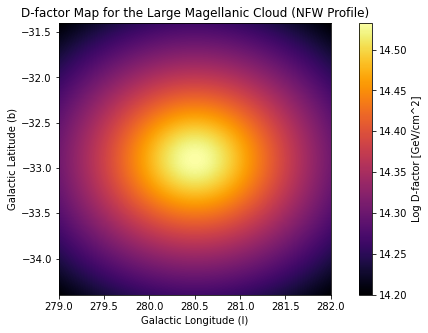

Total D-factor within 1 degree radius around the LMC center: 9.45e+22 MeV/cm^2


In [26]:
# Define the NFW profile
def nfw_profile(r, rho0=rho0, rs=rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

# Function to compute the distance to the LMC center
def distance_to_lmc_center(los, x_lmc, y_lmc, z_lmc, l, b):
    # Coordinates of the current point along the line of sight
    coord = SkyCoord(l=l*u.degree, b=b*u.degree, distance=los*u.kpc, frame = 'galactic') #frame='galactic')
    
    #coord = SkyCoord(l*u.degree, b*u.degree, distance=los*u.kpc, frame = 'icrs') #frame='galactic')
    
    x, y, z = coord.cartesian.x.value, coord.cartesian.y.value, coord.cartesian.z.value
    return np.sqrt((x - x_lmc)**2 + (y - y_lmc)**2 + (z - z_lmc)**2)

# Function to integrate the density along the line of sight
def d_factor_integrand(los, x_lmc, y_lmc, z_lmc, l, b, rho0, rs):
    r = distance_to_lmc_center(los, x_lmc, y_lmc, z_lmc, l, b)
    return nfw_profile(r, rho0, rs)

# Vectorized function to compute the D-factor for given coordinates
def compute_d_factor(l_vals, b_vals, distance_to_LMC):
    # Coordinates of the LMC center
    coord_lmc = SkyCoord(l=l_center*u.degree, b=b_center*u.degree, distance=distance_to_LMC*u.kpc, frame='galactic')
    
    #coord_lmc = SkyCoord(l_center*u.degree, b_center*u.degree, distance=distance_to_LMC*u.kpc, frame='icrs')
    
    x_lmc, y_lmc, z_lmc = coord_lmc.cartesian.x.value, coord_lmc.cartesian.y.value, coord_lmc.cartesian.z.value
    
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    s_vals = np.linspace(0, 2 * distance_to_LMC, 100)  # Discretize the integration range
    
    # Compute integrand values for all (l, b) pairs and s values
    integrand_vals = np.zeros((len(s_vals), len(b_vals), len(l_vals)))
    for i, s in enumerate(s_vals):
        integrand_vals[i] = d_factor_integrand(s, x_lmc, y_lmc, z_lmc, l_grid, b_grid, rho0, rs)
    
    # Integrate using the trapezoidal rule along the s dimension
    D_map = np.trapz(integrand_vals, s_vals, axis=0)
    
    # Calculate pixel area in degrees squared
    pixel_area_degrees2 = (l_vals[1] - l_vals[0]) * (b_vals[1] - b_vals[0])
    
    
    # Convert D-factor
    D_map *= pixel_area_degrees2
    
    return D_map

# Function to sum the D-factors within a given radius (in degrees) around the specified center
def sum_d_factor_in_radius(D_map, l_vals, b_vals, l_center, b_center, radius_deg):
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    distances = np.sqrt((l_grid - l_center)**2 + (b_grid - b_center)**2)
    within_radius = distances <= radius_deg
    return np.sum(D_map[within_radius])

# Define the grid of (l, b) values around the LMC center
l_vals = np.linspace(l_center - 1.5, l_center + 1.5, 1000)
b_vals = np.linspace(b_center - 1.5, b_center + 1.5, 1000)

# Compute the D-factor map
D_map = fromkpctocm * compute_d_factor(l_vals, b_vals, distance_to_LMC)

# Plot the D-factor map
plt.figure(figsize=(10, 5))
plt.imshow(np.log10(D_map), extent=[l_vals.min(), l_vals.max(), b_vals.min(), b_vals.max()], origin='lower', cmap='inferno')
plt.colorbar(label='Log D-factor [GeV/cm^2]')
plt.xlabel('Galactic Longitude (l)')
plt.ylabel('Galactic Latitude (b)')
plt.title('D-factor Map for the Large Magellanic Cloud (NFW Profile)')
plt.grid(False)
plt.show()

# Sum the D-factors within 1 degree radius around the LMC center
radius_deg = 1 # degrees
total_d_factor = 1e3 * sum_d_factor_in_radius(D_map, l_vals, b_vals, l_center, b_center, radius_deg)
print(f"Total D-factor within {radius_deg} degree radius around the LMC center: {total_d_factor:.2e} MeV/cm^2")


In [34]:
10**14.5 * 1e3

3.1622776601683795e+17

In [29]:
l_example = [-285.5, -285.5 -1.5/1000 ]
b_example = [-33, -33 -1.5/1000 ]

In [32]:
compute_d_factor(l_example, b_example, distance_to_LMC)

array([[8.23794673e-11, 8.23799394e-11],
       [8.23807925e-11, 8.23812646e-11]])

# Alternative definition of 1 degree region

Here I change my definition of distance, using astropy routine. I also printed the D-factor in the central bin, which Marco T said was similar to what he had, around $3 \times 10^{17} \, \rm MeV/cm^2$

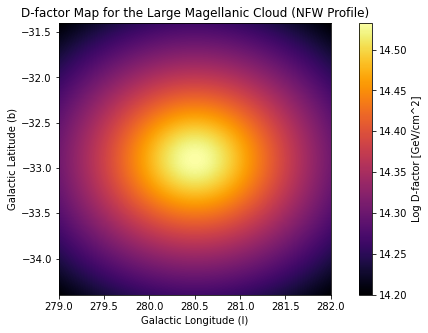

Total D-factor within 1 degree radius around the LMC center: 1.10e+23 MeV/cm^2
Central point D-factor: 3.41e+14 GeV/cm^2


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

# Constants
rho0 = 0.193909 * 1e-3  # GeV/cm^3
rs = 9.8  # kpc
distance_to_LMC = 50  # kpc
fromkpctocm = 3.0856775814913673 * 1e21

# Center of the LMC in galactic coordinates
l_center = 280.5  # degrees
b_center = -32.9  # degrees

# Define the NFW profile
def nfw_profile(r, rho0=rho0, rs=rs):
    return rho0 / ((r / rs) * (1 + r / rs)**2)

# Function to compute the distance to the LMC center
def distance_to_lmc_center(los, x_lmc, y_lmc, z_lmc, l, b):
    coord = SkyCoord(l=l*u.degree, b=b*u.degree, distance=los*u.kpc, frame='galactic')
    x, y, z = coord.cartesian.x.value, coord.cartesian.y.value, coord.cartesian.z.value
    return np.sqrt((x - x_lmc)**2 + (y - y_lmc)**2 + (z - z_lmc)**2)

# Function to integrate the density along the line of sight
def d_factor_integrand(los, x_lmc, y_lmc, z_lmc, l, b, rho0, rs):
    r = distance_to_lmc_center(los, x_lmc, y_lmc, z_lmc, l, b)
    return nfw_profile(r, rho0, rs)

# Vectorized function to compute the D-factor for given coordinates
def compute_d_factor(l_vals, b_vals, distance_to_LMC):
    coord_lmc = SkyCoord(l=l_center*u.degree, b=b_center*u.degree, distance=distance_to_LMC*u.kpc, frame='galactic')
    x_lmc, y_lmc, z_lmc = coord_lmc.cartesian.x.value, coord_lmc.cartesian.y.value, coord_lmc.cartesian.z.value
    
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    s_vals = np.linspace(0, 2 * distance_to_LMC, 100)
    
    integrand_vals = np.zeros((len(s_vals), len(b_vals), len(l_vals)))
    for i, s in enumerate(s_vals):
        integrand_vals[i] = d_factor_integrand(s, x_lmc, y_lmc, z_lmc, l_grid, b_grid, rho0, rs)
    
    D_map = np.trapz(integrand_vals, s_vals, axis=0)
    
    pixel_area_degrees2 = (l_vals[1] - l_vals[0]) * (b_vals[1] - b_vals[0])
    D_map *= pixel_area_degrees2
    
    return D_map

# Function to sum the D-factors within a given angular radius around the specified center
def sum_d_factor_in_radius(D_map, l_vals, b_vals, l_center, b_center, radius_deg):
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    coord_grid = SkyCoord(l=l_grid*u.degree, b=b_grid*u.degree, frame='galactic')
    coord_center = SkyCoord(l=l_center*u.degree, b=b_center*u.degree, frame='galactic')
    
    angular_separation = coord_grid.separation(coord_center).degree
    within_radius = angular_separation <= radius_deg
    
    return np.sum(D_map[within_radius])

# Define the grid of (l, b) values around the LMC center
l_vals = np.linspace(l_center - 1.5, l_center + 1.5, 1000)
b_vals = np.linspace(b_center - 1.5, b_center + 1.5, 1000)

# Compute the D-factor map
D_map = fromkpctocm * compute_d_factor(l_vals, b_vals, distance_to_LMC)

# Plot the D-factor map
plt.figure(figsize=(10, 5))
plt.imshow(np.log10(D_map), extent=[l_vals.min(), l_vals.max(), b_vals.min(), b_vals.max()], origin='lower', cmap='inferno')
plt.colorbar(label='Log D-factor [GeV/cm^2]')
plt.xlabel('Galactic Longitude (l)')
plt.ylabel('Galactic Latitude (b)')
plt.title('D-factor Map for the Large Magellanic Cloud (NFW Profile)')
plt.grid(False)
plt.show()

# Sum the D-factors within 1 degree radius around the LMC center
radius_deg = 1  # degrees
total_d_factor = 1e3 * sum_d_factor_in_radius(D_map, l_vals, b_vals, l_center, b_center, radius_deg)
print(f"Total D-factor within {radius_deg} degree radius around the LMC center: {total_d_factor:.2e} MeV/cm^2")

# Optional: Print the central point in D_map for verification
l_idx = (np.abs(l_vals - l_center)).argmin()
b_idx = (np.abs(b_vals - b_center)).argmin()
central_d_factor = D_map[b_idx, l_idx]
print(f"Central point D-factor: {central_d_factor:.2e} GeV/cm^2")


# Define masks around some points

Here I simply define a mask around some given points with coordinate [l,b]

In [179]:
def mask_multiple_regions(D_map, l_vals, b_vals, mask_centers, mask_radius_deg):
    D_map_copy = D_map.copy()
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    
    for (mask_l_center, mask_b_center) in mask_centers:
        distances = np.sqrt((l_grid - mask_l_center)**2 + (b_grid - mask_b_center)**2)
        mask = distances <= mask_radius_deg
        D_map_copy[mask] = np.nan  # Mask the region by setting D-factor to NaN for better visualization
    
    return D_map_copy


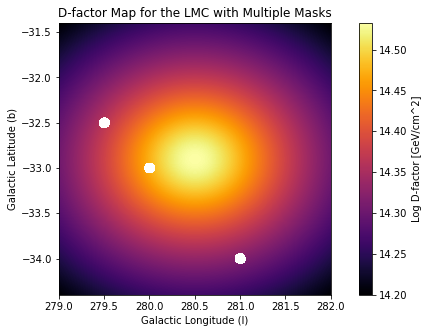

In [181]:
# List of mask centers
mask_centers = [(280.0, -33.0), (281.0, -34.0), (279.5, -32.5)]
mask_radius_deg = 0.05

D_map_masked = mask_multiple_regions(D_map, l_vals, b_vals, mask_centers, mask_radius_deg)

# Plot the masked D-factor map
plt.figure(figsize=(10, 5))
plt.imshow(np.log10(D_map_masked), extent=[l_vals.min(), l_vals.max(), b_vals.min(), b_vals.max()], origin='lower', cmap='inferno')
plt.colorbar(label='Log D-factor [GeV/cm^2]')
plt.xlabel('Galactic Longitude (l)')
plt.ylabel('Galactic Latitude (b)')
plt.title('D-factor Map for the LMC with Multiple Masks')
plt.grid(False)
plt.show()

# Mask depending on D-factor (still to be fixed)

In [ ]:
def mask_multiple_regions(D_map, l_vals, b_vals, mask_centers, mask_radius_deg):
    D_map_copy = D_map.copy()
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    
    for (mask_l_center, mask_b_center) in mask_centers:
        distances = np.sqrt((l_grid - mask_l_center)**2 + (b_grid - mask_b_center)**2)
        mask = distances <= mask_radius_deg
        D_map_copy[mask] = np.nan  # Mask the region by setting D-factor to NaN for better visualization
    
    return D_map_copy



In [167]:
def mask_multiple_regions(Dmap, l_vals, b_vals, mask_centers, initial_radius, threshold, rescale):
    D_map_copy = Dmap.copy()
    l_grid, b_grid = np.meshgrid(l_vals, b_vals)
    
    for (mask_l_center, mask_b_center) in mask_centers:
        
        distances = np.sqrt((l_grid - mask_l_center)**2 + (b_grid - mask_b_center)**2)
        mask = distances <= initial_radius
        D_factor_sum = np.nansum(D_map_copy[mask])
        if D_factor_sum <= threshold:
            D_map_copy[mask] = np.nan
            break
        else:
            radius = initial_radius* rescale
            mask2 = distances <= radius
            D_map_copy[mask2] = np.nan
    
    return D_map_copy

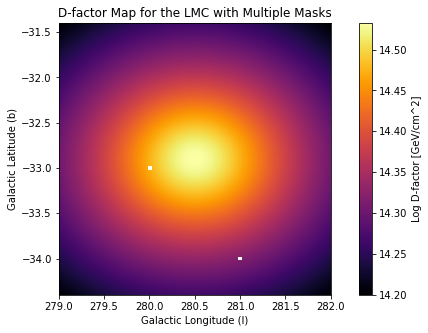

In [177]:
# List of mask centers
mask_centers = [(280.0, -33.0), (281.0, -34.0), (279.5, -32.5)]
mask_radius_deg = 0.01

D_map_masked = mask_multiple_regions(D_map, l_vals, b_vals, mask_centers, mask_radius_deg, 1e16, 1.5)

# Plot the masked D-factor map
plt.figure(figsize=(10, 5))
plt.imshow(np.log10(D_map_masked), extent=[l_vals.min(), l_vals.max(), b_vals.min(), b_vals.max()], origin='lower', cmap='inferno')
plt.colorbar(label='Log D-factor [GeV/cm^2]')
plt.xlabel('Galactic Longitude (l)')
plt.ylabel('Galactic Latitude (b)')
plt.title('D-factor Map for the LMC with Multiple Masks')
plt.grid(False)
plt.show()